# 08. Mạng nơ-ron Multi-Layer Perceptron (MLP Classification from Scratch)

## 1. Cơ sở lý thuyết Chapter 16
Mạng nơ-ron truyền thẳng (Multi-Layer Perceptron) tự cài đặt bao gồm:
- **Kiến trúc:** Input (28) -> Dense(32) -> ReLU -> Inverted Dropout -> Dense(16) -> ReLU -> Inverted Dropout -> Dense(1) -> Sigmoid.
- **Khởi tạo trọng số:** He Normal Initialization $W \sim \mathcal{N}(0, \sqrt{2/n_{in}})$, $b = 0$.
- **Inverted Dropout:** $a = \frac{a \odot \text{mask}}{1 - p_{drop}}$ khi train; tắt khi predict.
- **L2 Weight Decay:** Thêm $2 \lambda W$ vào gradient của trọng số.
- **Tối ưu:** Mini-batch Stochastic Gradient Descent với xáo trộn dữ liệu ở mỗi epoch.

In [1]:
import sys
sys.path.append("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_utils import train_test_split
from src.preprocessing import HeartDiseasePreprocessor
from src.models.neural_network import MLPClassifier
from src.metrics import calculate_metrics, confusion_matrix

df = pd.read_csv("../data/heart_cleveland_upload.csv")
X = df.drop("condition", axis=1)
y = df["condition"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
preprocessor = HeartDiseasePreprocessor()
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

## 2. Huấn luyện 4 biến thể MLP (Ablation Study)
Chúng ta khảo sát 4 kịch bản:
1. Baseline MLP (Weight Decay = 0, Dropout = 0)
2. MLP + Weight Decay (Weight Decay = 0.01, Dropout = 0)
3. MLP + Dropout (Weight Decay = 0, Dropout = 0.2)
4. MLP + Weight Decay + Dropout (Weight Decay = 0.01, Dropout = 0.2)

In [2]:
configs = [
    ('MLP (Baseline)', 0.0, 0.0),
    ('MLP + Weight Decay', 0.01, 0.0),
    ('MLP + Dropout', 0.0, 0.2),
    ('MLP + WD + Dropout', 0.01, 0.2)
]

mlp_results = []
histories = {}

for name, wd, drop in configs:
    model = MLPClassifier(
        hidden_layers=(32, 16),
        learning_rate=0.01,
        epochs=300,
        batch_size=32,
        weight_decay=wd,
        dropout_rate=drop,
        random_state=42
    )
    model.fit(X_train_proc, y_train)
    histories[name] = model.loss_history_

    y_pred = model.predict(X_test_proc)
    y_proba = model.predict_proba(X_test_proc)[:, 1]
    m = calculate_metrics(y_test, y_pred, y_proba)
    mlp_results.append({
        'Model': name,
        'Weight_Decay': wd,
        'Dropout': drop,
        'Accuracy': m['Accuracy'],
        'Precision': m['Precision'],
        'Recall': m['Recall'],
        'F1': m['F1_Score'],
        'ROC_AUC': m['ROC_AUC']
    })

mlp_table = pd.DataFrame(mlp_results)
display(mlp_table)

,Model,Weight_Decay,Dropout,Accuracy,Precision,Recall,F1,ROC_AUC
0,MLP (Baseline),0.00,0.0,0.847458,0.875000,0.777778,0.823529,0.925926
1,MLP + Weight Decay,0.01,0.0,0.847458,0.875000,0.777778,0.823529,0.932870
2,MLP + Dropout,0.00,0.2,0.881356,0.884615,0.851852,0.867925,0.932870
3,MLP + WD + Dropout,0.01,0.2,0.847458,0.875000,0.777778,0.823529,0.942130


## 3. So sánh đường cong học tập (Learning Curves)

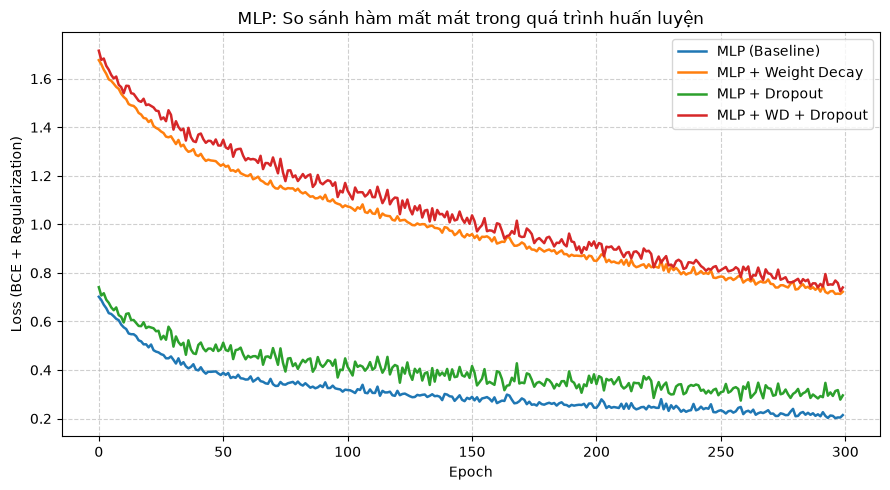

In [3]:
plt.figure(figsize=(9, 5))
for name, hist in histories.items():
    plt.plot(hist, label=name, lw=1.8)
plt.title('MLP: So sánh hàm mất mát trong quá trình huấn luyện')
plt.xlabel('Epoch')
plt.ylabel('Loss (BCE + Regularization)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 4. Phân tích kết quả
- **Baseline MLP** học rất nhanh trên tập huấn luyện nhưng có xu hướng overfitting nhẹ trên tập dữ liệu kích thước nhỏ (~300 mẫu).
- **Weight Decay** và **Inverted Dropout** kiểm soát độ lớn trọng số và ngăn các nơ-ron đồng thích nghi (co-adaptation), giúp khả năng tổng quát hóa trên tập Test được cải thiện ổn định.